<a href="https://colab.research.google.com/github/ymuto0302/PJ2025/blob/main/mvtec_anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## MVTec AD に対する異常検知

In [ ]:
import os
import glob
import argparse

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

In [ ]:
# =============================================================================
# 1. SSIM(構造的類似度) の実装
# -----------------------------------------------------------------------------
# SSIM は 2 枚の画像の局所的な (a)輝度, (b)コントラスト, および (c)構造 の一致度を測る。
# ポイント：局所統計量(平均・分散・共分散)をガウス窓による畳み込みで求める。
# 「画素単位の SSIM マップ」を返すよう実装し，これを損失にも異常マップにも流用する。
# =============================================================================

def _gaussian_window(window_size: int, sigma: float) -> torch.Tensor:
    """1次元ガウスカーネルを生成して正規化する."""
    coords = torch.arange(window_size, dtype=torch.float32) - window_size // 2
    g = torch.exp(-(coords ** 2) / (2.0 * sigma ** 2))
    return g / g.sum()


def _create_window(window_size: int, channel: int, sigma: float = 1.5) -> torch.Tensor:
    """2次元ガウス窓を (channel, 1, k, k) の畳み込みカーネル形状で作る."""
    _1d = _gaussian_window(window_size, sigma).unsqueeze(1)        # (k, 1)
    _2d = (_1d @ _1d.t()).unsqueeze(0).unsqueeze(0)                # (1, 1, k, k)
    window = _2d.expand(channel, 1, window_size, window_size).contiguous()
    return window


def ssim_map(x: torch.Tensor, y: torch.Tensor, window: torch.Tensor,
             window_size: int, channel: int,
             C1: float = 0.01 ** 2, C2: float = 0.03 ** 2) -> torch.Tensor:
    """画素単位の SSIM マップを返す.

    入力 x, y は [0, 1] に正規化された (N, C, H, W) を想定する.
    出力は (N, C, H, W) の SSIM マップ(値域はおおむね [-1, 1], 1 が完全一致).
    """
    pad = window_size // 2
    # 局所平均 mu
    mu_x = F.conv2d(x, window, padding=pad, groups=channel)
    mu_y = F.conv2d(y, window, padding=pad, groups=channel)
    mu_x2, mu_y2, mu_xy = mu_x.pow(2), mu_y.pow(2), mu_x * mu_y
    # 局所分散・共分散 (E[X^2]-E[X]^2 の形で計算する)
    sigma_x2 = F.conv2d(x * x, window, padding=pad, groups=channel) - mu_x2
    sigma_y2 = F.conv2d(y * y, window, padding=pad, groups=channel) - mu_y2
    sigma_xy = F.conv2d(x * y, window, padding=pad, groups=channel) - mu_xy
    # SSIM の定義式
    numerator = (2 * mu_xy + C1) * (2 * sigma_xy + C2)
    denominator = (mu_x2 + mu_y2 + C1) * (sigma_x2 + sigma_y2 + C2)
    return numerator / denominator


class SSIMLoss(nn.Module):
    """1 - mean(SSIM) を損失として返す. SSIM が高い(=似ている)ほど損失は小さい."""

    def __init__(self, window_size: int = 11, channel: int = 1, sigma: float = 1.5):
        super().__init__()
        self.window_size = window_size
        self.channel = channel
        self.register_buffer("window", _create_window(window_size, channel, sigma))

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        s = ssim_map(x, y, self.window, self.window_size, self.channel)
        return 1.0 - s.mean()


In [ ]:
# =============================================================================
# 2. Convolutional Autoencoder の定義
# -----------------------------------------------------------------------------
# bottleneck の幅 (latent_dim) を絞るほど AE の表現力が制限され，
# 異常を再構成しにくくなる(=異常が検出しやすくなる)。逆に広げると異常まで再構成してしまう。
# =============================================================================

class ConvAutoencoder(nn.Module):
    """入力 256x256 を 5 回 stride-2 で 8x8 まで畳み込み, ボトルネックを経て復元する."""

    def __init__(self, in_channels: int = 1, latent_dim: int = 128, base: int = 32):
        super().__init__()

        def enc_block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(cout),
                nn.LeakyReLU(0.2, inplace=True),
            )

        def dec_block(cin, cout):
            return nn.Sequential(
                nn.ConvTranspose2d(cin, cout, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
            )

        # エンコーダ: 256 -> 128 -> 64 -> 32 -> 16 -> 8
        self.encoder = nn.Sequential(
            enc_block(in_channels, base),       # 128
            enc_block(base, base * 2),          # 64
            enc_block(base * 2, base * 4),       # 32
            enc_block(base * 4, base * 4),       # 16
            enc_block(base * 4, base * 8),       # 8
        )
        # ボトルネック: 8x8 の特徴を latent_dim へ圧縮し, 再び 8x8 へ戻す
        self.to_latent = nn.Conv2d(base * 8, latent_dim, kernel_size=8)   # 8x8 -> 1x1
        self.from_latent = nn.ConvTranspose2d(latent_dim, base * 8, kernel_size=8)  # 1x1 -> 8x8

        # デコーダ: 8 -> 16 -> 32 -> 64 -> 128 -> 256
        self.decoder = nn.Sequential(
            dec_block(base * 8, base * 4),       # 16
            dec_block(base * 4, base * 4),       # 32
            dec_block(base * 4, base * 2),       # 64
            dec_block(base * 2, base),           # 128
            nn.ConvTranspose2d(base, in_channels, kernel_size=4, stride=2, padding=1),  # 256
            nn.Sigmoid(),                        # 出力を [0, 1] に収める
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.encoder(x)
        z = self.to_latent(z)
        z = self.from_latent(z)
        return self.decoder(z)


In [ ]:
# =============================================================================
# 3. MVTec AD データセット
# -----------------------------------------------------------------------------
# 学習時は train/good のみを読み込む。テスト時は test 配下の全画像を読み,
# 欠陥ならば対応する GT マスクを，正常(good)なら全 0 のマスクを返す。
# =============================================================================

class MVTecDataset(Dataset):
    def __init__(self, root: str, category: str, split: str = "train",
                 image_size: int = 256, grayscale: bool = True):
        self.image_size = image_size
        self.grayscale = grayscale
        self.split = split

        cat_dir = os.path.join(root, category)
        self.samples = []  # (image_path, mask_path_or_None, label)  label: 0=正常, 1=異常

        if split == "train":
            for p in sorted(glob.glob(os.path.join(cat_dir, "train", "good", "*.png"))):
                self.samples.append((p, None, 0))
        else:  # test
            test_dir = os.path.join(cat_dir, "test")
            gt_dir = os.path.join(cat_dir, "ground_truth")
            for defect_type in sorted(os.listdir(test_dir)):
                img_paths = sorted(glob.glob(os.path.join(test_dir, defect_type, "*.png")))
                for p in img_paths:
                    if defect_type == "good":
                        self.samples.append((p, None, 0))
                    else:
                        stem = os.path.splitext(os.path.basename(p))[0]
                        mask_p = os.path.join(gt_dir, defect_type, f"{stem}_mask.png")
                        mask_p = mask_p if os.path.exists(mask_p) else None
                        self.samples.append((p, mask_p, 1))

    def __len__(self) -> int:
        return len(self.samples)

    def _load_image(self, path: str) -> torch.Tensor:
        mode = "L" if self.grayscale else "RGB"
        img = Image.open(path).convert(mode).resize(
            (self.image_size, self.image_size), Image.BILINEAR)
        arr = np.asarray(img, dtype=np.float32) / 255.0
        if self.grayscale:
            arr = arr[None, :, :]                 # (1, H, W)
        else:
            arr = arr.transpose(2, 0, 1)          # (3, H, W)
        return torch.from_numpy(arr)

    def _load_mask(self, path, label) -> torch.Tensor:
        if label == 0 or path is None:
            return torch.zeros(1, self.image_size, self.image_size)
        m = Image.open(path).convert("L").resize(
            (self.image_size, self.image_size), Image.NEAREST)
        m = (np.asarray(m, dtype=np.float32) > 0).astype(np.float32)
        return torch.from_numpy(m[None, :, :])

    def __getitem__(self, idx: int):
        img_path, mask_path, label = self.samples[idx]
        image = self._load_image(img_path)
        mask = self._load_mask(mask_path, label)
        return image, mask, label


In [ ]:
# =============================================================================
# 4. 学習ループ
# =============================================================================

def train(model, loader, device, epochs, lr, loss_type, in_channels):
    model.to(device).train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    criterion = SSIMLoss(window_size=11, channel=in_channels).to(device)
    '''
    if loss_type == "ssim":
        criterion = SSIMLoss(window_size=11, channel=in_channels).to(device)
    else:
        criterion = nn.MSELoss()
    '''

    for epoch in range(1, epochs + 1):
        running = 0.0
        for images, _, _ in loader:
            images = images.to(device)
            recon = model(images)
            loss = criterion(recon, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running += loss.item() * images.size(0)

        print(f"[epoch {epoch:3d}/{epochs}] {loss_type}-loss = {running / len(loader.dataset):.4f}")
    return model


In [ ]:
# =============================================================================
# 5. 異常マップの生成
# -----------------------------------------------------------------------------
# L2: 入力と再構成の画素ごとの二乗誤差
# SSIM: 1 - SSIM マップ。局所構造の不一致が大きいほど高値になる.
# いずれもガウシアン平滑化でノイズを抑え, 空間的に滑らかなマップにする。
# =============================================================================

@torch.no_grad()
def compute_anomaly_map(model, image, device, score_type, in_channels):
    model.eval()
    image = image.to(device)
    recon = model(image)

    window = _create_window(11, in_channels).to(device)
    s = ssim_map(image, recon, window, 11, in_channels)   # (N, C, H, W)
    amap = (1.0 - s).mean(dim=1, keepdim=True)            # チャネル方向に集約
    '''
    if score_type == "ssim":
        window = _create_window(11, in_channels).to(device)
        s = ssim_map(image, recon, window, 11, in_channels)   # (N, C, H, W)
        amap = (1.0 - s).mean(dim=1, keepdim=True)            # チャネル方向に集約
    else:  # l2
        amap = ((image - recon) ** 2).mean(dim=1, keepdim=True)
    '''

    # ガウシアン平滑化(分離可能カーネルを 2 回の conv で適用)
    k = _gaussian_window(7, sigma=2.0).to(device)
    kx = k.view(1, 1, 1, -1)
    ky = k.view(1, 1, -1, 1)
    amap = F.conv2d(amap, kx, padding=(0, 3))
    amap = F.conv2d(amap, ky, padding=(3, 0))
    return amap.cpu(), recon.cpu()


In [ ]:
# =============================================================================
# 6. 評価 (image-level / pixel-level AUROC)
# -----------------------------------------------------------------------------
# image-level: 各画像の異常スコア(マップの最大値)と正常/異常ラベルから AUROC を求める
# pixel-level: 全画素の異常スコアと GT マスク(0/1)から AUROC を求める
# =============================================================================

@torch.no_grad()
def evaluate(model, dataset, device, score_type, in_channels, batch_size=8):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)n

    image_scores, image_labels = [], []
    pixel_scores, pixel_labels = [], []

    for images, masks, labels in loader:
        amap, _ = compute_anomaly_map(model, images, device, score_type, in_channels)
        amap_np = amap.squeeze(1).numpy()          # (N, H, W)
        masks_np = masks.squeeze(1).numpy()        # (N, H, W)

        for i in range(amap_np.shape[0]):
            image_scores.append(float(amap_np[i].max()))
            image_labels.append(int(labels[i]))
            pixel_scores.append(amap_np[i].ravel())
            pixel_labels.append(masks_np[i].ravel())

    img_auroc = roc_auc_score(image_labels, image_scores)

    px_scores = np.concatenate(pixel_scores)
    px_labels = np.concatenate(pixel_labels).astype(int)
    # 正常画像のみだとマスクが全 0 になり pixel-AUROC が定義できないので確認する
    pix_auroc = roc_auc_score(px_labels, px_scores) if px_labels.max() > 0 else float("nan")

    print(f"image-level AUROC = {img_auroc:.4f}")
    print(f"pixel-level AUROC = {pix_auroc:.4f}")
    return img_auroc, pix_auroc


In [ ]:
# =============================================================================
# 7. 可視化 (入力 / 再構成 / 異常マップ / GT マスク)
# =============================================================================

@torch.no_grad()
def visualize(model, dataset, device, score_type, in_channels, n=4, save_path="anomaly_vis.png"):
    # 異常サンプル(label==1)を優先的に取り出す
    idxs = [i for i, s in enumerate(dataset.samples) if s[2] == 1][:n]
    if len(idxs) < n:
        idxs += [i for i in range(len(dataset)) if i not in idxs][:n - len(idxs)]

    fig, axes = plt.subplots(len(idxs), 4, figsize=(12, 3 * len(idxs)))
    if len(idxs) == 1:
        axes = axes[None, :]
    col_titles = ["input", "reconstruction", "anomaly map", "ground truth"]

    for row, idx in enumerate(idxs):
        image, mask, _ = dataset[idx]
        amap, recon = compute_anomaly_map(model, image.unsqueeze(0), device,
                                          score_type, in_channels)
        amap = amap.squeeze().numpy()
        recon = recon.squeeze().numpy()
        img_np = image.squeeze().numpy()

        cmap = "gray" if in_channels == 1 else None
        if in_channels == 3:
            img_np = np.transpose(img_np, (1, 2, 0))
            recon = np.transpose(recon, (1, 2, 0))

        axes[row, 0].imshow(img_np, cmap=cmap)
        axes[row, 1].imshow(recon, cmap=cmap)
        axes[row, 2].imshow(amap, cmap="jet")
        axes[row, 3].imshow(mask.squeeze().numpy(), cmap="gray")
        for c in range(4):
            axes[row, c].axis("off")
            if row == 0:
                axes[row, c].set_title(col_titles[c])

    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    print(f"可視化結果の保存先: {save_path}")


device=cuda, category=carpet, loss=ssim, latent_dim=128
train=280 枚(正常のみ), test=117 枚
[epoch   1/100] ssim-loss = 0.8823
[epoch   2/100] ssim-loss = 0.6212
[epoch   3/100] ssim-loss = 0.5463
[epoch   4/100] ssim-loss = 0.5101
[epoch   5/100] ssim-loss = 0.4967
[epoch   6/100] ssim-loss = 0.4617
[epoch   7/100] ssim-loss = 0.3940
[epoch   8/100] ssim-loss = 0.3570
[epoch   9/100] ssim-loss = 0.3398
[epoch  10/100] ssim-loss = 0.3237
[epoch  11/100] ssim-loss = 0.3145
[epoch  12/100] ssim-loss = 0.3071
[epoch  13/100] ssim-loss = 0.3022
[epoch  14/100] ssim-loss = 0.2963
[epoch  15/100] ssim-loss = 0.2900
[epoch  16/100] ssim-loss = 0.2847
[epoch  17/100] ssim-loss = 0.2786
[epoch  18/100] ssim-loss = 0.2739
[epoch  19/100] ssim-loss = 0.2708
[epoch  20/100] ssim-loss = 0.2663
[epoch  21/100] ssim-loss = 0.2643
[epoch  22/100] ssim-loss = 0.2594
[epoch  23/100] ssim-loss = 0.2556
[epoch  24/100] ssim-loss = 0.2510
[epoch  25/100] ssim-loss = 0.2480
[epoch  26/100] ssim-loss = 0.2462
[epo

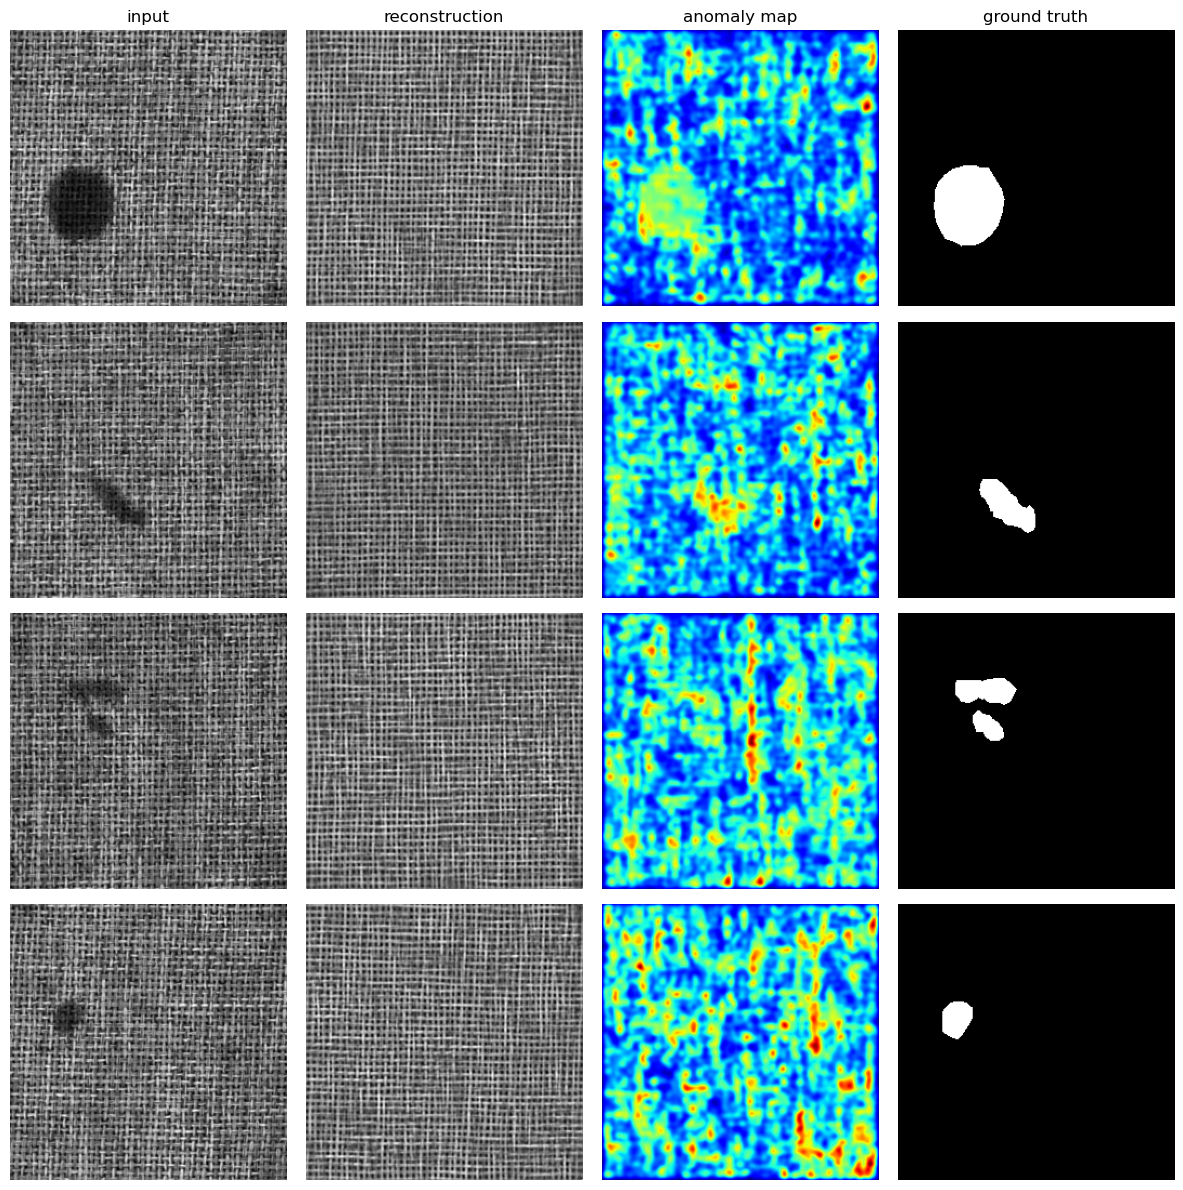

In [ ]:
# =============================================================================
# 8. メイン
# =============================================================================

class Config():
    data_root = "mvtec_ad" # MVTec AD のルートディレクトリ
    category = "carpet" # カテゴリ名(例: carpet, wood, tile)
    image_size = 256
    grayscale = True # グレースケールで扱う際は True
    rgb = False # RGB で扱う際は True
    latent_dim = 128 # ボトルネック幅
    loss_type = "ssim" # (メモ) ["ssim", "l2"] の両方を作る

    epochs = 100
    batch_size = 8
    lr = 2e-4

def main():
    # 設定の読み込み
    config = Config()

    # デバイスのチェック
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 入力チャネル数の設定
    in_channels = 1 if config.grayscale else 3
    print(f"device={device}, category={config.category}, loss={config.loss_type}, latent_dim={config.latent_dim}")

    # Dataset の生成
    train_set = MVTecDataset(config.data_root, config.category, "train",
                             config.image_size, config.grayscale)
    test_set = MVTecDataset(config.data_root, config.category, "test",
                            config.image_size, config.grayscale)

    # DataLoader の設定
    train_loader = DataLoader(train_set, batch_size=config.batch_size, shuffle=True)
    print(f"train={len(train_set)} 枚(正常のみ), test={len(test_set)} 枚")

    # モデル生成と学習
    model = ConvAutoencoder(in_channels=in_channels, latent_dim=config.latent_dim)
    model = train(model, train_loader, device, config.epochs, config.lr,
                  config.loss_type, in_channels)

    # モデル評価
    evaluate(model, test_set, device, config.loss_type, in_channels, config.batch_size)

    # 結果の可視化
    visualize(model, test_set, device, config.loss_type, in_channels, n=4)


if __name__ == "__main__":
    main()
